## Intro to text mining - Part 1 - Exercises

## Exercise 1

#### Task 1
##### Import the required packages.
##### Set the working directory to data directory.
##### Print the working directory.

In [1]:
#=================================================-
#### Slide 17: Loading packages  ####

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import nltk.data
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

In [2]:
data_dir = Path.cwd().parent / "data"

In [5]:
#=================================================-
#### Slide 28: Loading text data  ####

# Load corpus from a csv (for Mac).

un = pd.read_csv(data_dir / 'UN_agreement_titles.csv')
un.columns

Index(['title', 'reg_number'], dtype='object')

#### Result:

#### Task 2
#####  Load the corpus from `UN_agreement_titles.csv` into a new variable `agreements` .
#####  Print the columns of `agreements`.
#####  Print the first 5 rows and check the output to see if data is loaded correctly.

### Result:

In [6]:
un.head()

,title,reg_number
0,Agreement concerning arrangements for the hold...,1
1,Declaration recognizing as compulsory the juri...,1
2,Declaration renewing for a further period of f...,1
3,Declaration recognizing as compulsory the juri...,10
4,Convention between the United Kingdom and Fran...,10


#### Task 3
##### Make a series from the dataframe that contains only the `title` column of `agreements` and name it `titles`.
##### Print the first 5 titles. 

In [8]:
17762190028

In [9]:
titles.head()

0    Agreement concerning arrangements for the hold...
1    Declaration recognizing as compulsory the juri...
2    Declaration renewing for a further period of f...
3    Declaration recognizing as compulsory the juri...
4    Convention between the United Kingdom and Fran...
Name: title, dtype: object

#### Result:

## Exercise 2

#### Task 1
##### Tokenize each title in the series `titles` and assign it to `titles_tokenized`.
##### Assign the first tokenized titles to `title_words` and print this out.

#### Task 2
##### Clean the `titles_words` in the following order:
##### 1. Convert all characters to lower case and assign it to `titles_words`
##### 2. Remove stop words from `titles_words` and assign it to `titles_words`
##### 3. Remove punctuation, numbers, and all other symbols that are not letters of the alphabet 
#####    from `titles_words` and assign it to `titles_words`
##### 4. Stem words in `titles_words` and assign it to `titles_words`

#### Result:

In [28]:
titles_clean

[['agreement',
  'concern',
  'arrang',
  'hold',
  'fifth',
  'session',
  'council',
  'unit',
  'nation',
  'relief',
  'rehabilit',
  'administr',
  'palai',
  'de',
  'nation',
  'geneva',
  'conclud',
  'unit',
  'nation',
  'leagu',
  'nation',
  'unit',
  'nation',
  'relief',
  'rehabilit',
  'administr'],
 ['declar',
  'recogn',
  'compulsori',
  'jurisdict',
  'court',
  'conform',
  'articl',
  'paragraph',
  'statut',
  'intern',
  'court',
  'justic',
  'legal',
  'disput',
  'concern',
  'interpret',
  'applic',
  'valid',
  'treati',
  'relat',
  'boundari',
  'british',
  'hondura',
  'london',
  'februari'],
 ['declar',
  'renew',
  'period',
  'five',
  'year',
  'begin',
  'februari',
  'declar',
  'recogn',
  'compulsori',
  'jurisdict',
  'court',
  'conform',
  'articl',
  'paragraph',
  'statut',
  'intern',
  'court',
  'justic',
  'legal',
  'disput',
  'concern',
  'interpret',
  'applic',
  'valid',
  'treati',
  'relat',
  'boundari',
  'british',
  'hondur

## Exercise 3

#### Task 1

##### Initialize stop words and save it to a variable `stop_words`
##### Create an empty list `titles_clean` whose length is same as `titles_tokenized`.
##### Perform the above steps on the list `titles_tokenized` and also record the length of each title in 'word_counts_per_titles'.
##### Check the first 10 words in 300th title.

#### Result:

In [35]:
#=================================================-
#### Slide 56: Implementing pre-processing steps on a corpus  ####

stop_words = stopwords.words('english')

titles_clean = [[
    # Stem and convert to lower case
    PorterStemmer().stem(lowercase_word)
    # Iterate over words in documents
    for word in title
    # Create lowercase words and remove empty strings
    if (lowercase_word := word.lower())
    # Remove stop words
    if not lowercase_word in stop_words
    # Remove non-alphabetical words
    if lowercase_word.isalpha()
    ]
    # Iterate over documents
    for title in [word_tokenize(s) for s in titles]
    # Remove short documents
    if len(title) >= 3
]

word_counts_per_title = [len(i) for i in titles_clean]

In [36]:
word_counts_per_title[:10]

[26, 25, 32, 15, 17, 11, 15, 8, 7, 8]

#### Task 2
##### Print the first 10 rows of `word_counts_per_titles` .
##### Plot a histogram for  `word_counts_per_titles`, set bins to number of unique values in the list.

#### Result:

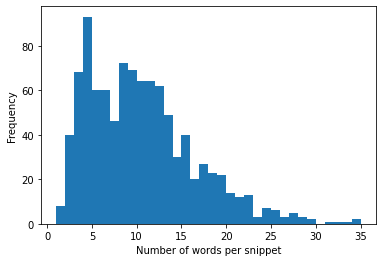

In [37]:
plt.hist(word_counts_per_title, bins = len(set(word_counts_per_title)))
plt.xlabel('Number of words per snippet')
plt.ylabel('Frequency');

#### Task 3
##### Convert word counts list and snippets list to numpy arrays named `ex_word_counts_array` and  `titles_array` and print the length of  `titles_array`.
##### Find indices of all snippets where there are greater than or equal to 3 words and save it to `valid_titles`. Print length of `valid_titles`.
##### Subset the `titles_array` to keep only those where there are at least 3 words. Print length of `titles_array`.
##### Convert it back to a list `titles_clean`.  Print first 5 rows of `valid_titles`.
##### Combine word tokens in each titles into a single string and save the result as a list called `titles_clean_list`. Print the first 5 titles in `titles_clean_list`.

#### Result:

#### Task 4
##### Use the function that takes a list of character strings
##### and a name of an output file and writes it into a txt file we defined in class.

#### Result:

In [38]:
out_file = data_dir / "clean_titles.txt"
titles_clean_list = [' '.join(title) for title in titles_clean]
out_text = '\n'.join(titles_clean_list)
out_file.write_text(out_text)
print(out_file.read_text())

agreement concern arrang hold fifth session council unit nation relief rehabilit administr palai de nation geneva conclud unit nation leagu nation unit nation relief rehabilit administr
declar recogn compulsori jurisdict court conform articl paragraph statut intern court justic legal disput concern interpret applic valid treati relat boundari british hondura london februari
declar renew period five year begin februari declar recogn compulsori jurisdict court conform articl paragraph statut intern court justic legal disput concern interpret applic valid treati relat boundari british hondura london februari
declar recogn compulsori jurisdict court conform articl paragraph statut intern court justic new york decemb
convent unit kingdom franc respect commerci relat franc seychel island sign london april denunci part unit kingdom
exchang note constitut agreement amend supplementingth agreement amend washington decemb januari
exchang note constitut agreement amend air transport agreement gov

##### Task 5
##### Save output file name to a variable `ex_out_filename` and call the text file "ex_clean_titles.txt".

#### Result:

#### Task 6

##### Save  `titles_tokenized` as pickle with the name `titles_tokenized.sav` ,`ex_word_counts_array` as `ex_word_counts_array.sav`, 

#### `titles_clean` as `titles_clean.sav`, `titles_clean_list` as `titles_clean_list.sav` for later use. 

#### Result:

In [40]:
#=================================================-
#### Slide 65: Pickle data to save our work  ####

out1 = data_dir / "titles_tokenized.pkl"
out2 = data_dir / "titles_word_count_list.pkl"
out3 = data_dir / "titles_clean.pkl"
out4 = data_dir / "titles_clean_list.pkl"
pickle.dump(titles_tokenized, out1.open("wb" ))
pickle.dump(word_counts_per_title, out2.open('wb'))
pickle.dump(titles_clean, out3.open('wb'))
pickle.dump(titles_clean_list, out4.open('wb'))
in1 = pickle.loads(out1.read_bytes())
in2 = pickle.loads(out2.read_bytes())
in3 = pickle.loads(out3.read_bytes())
in4 = pickle.loads(out4.read_bytes())

In [44]:
in1

[['Agreement',
  'concerning',
  'arrangements',
  'for',
  'the',
  'holding',
  'of',
  'the',
  'fifth',
  'session',
  'of',
  'the',
  'Council',
  'of',
  'the',
  'United',
  'Nations',
  'Relief',
  'and',
  'Rehabilitation',
  'Administration',
  'at',
  'the',
  'Palais',
  'des',
  'Nations',
  ',',
  'Geneva',
  ',',
  'concluded',
  'between',
  'the',
  'United',
  'Nations',
  ',',
  'the',
  'League',
  'of',
  'Nations',
  'and',
  'the',
  'United',
  'Nations',
  'Relief',
  'and',
  'Rehabilitation',
  'Administration'],
 ['Declaration',
  'recognizing',
  'as',
  'compulsory',
  'the',
  'jurisdiction',
  'of',
  'the',
  'Court',
  ',',
  'in',
  'conformity',
  'with',
  'Article',
  '36',
  ',',
  'paragraph',
  '2',
  ',',
  'of',
  'the',
  'Statute',
  'of',
  'the',
  'International',
  'Court',
  'of',
  'Justice',
  ',',
  'in',
  'all',
  'legal',
  'disputes',
  'concerning',
  'the',
  'interpretation',
  ',',
  'application',
  'or',
  'validity',
  'o